# Cox-BNN
## A Bayesian Neural Network for Sruvival Analysis

**Authors**: Alice Conighi, Emanuele Valea, Giovanni Zedda

<small>Final project for Probabilistic and Machine Learning course held by Prof. Luca Bortolussi at University of Trieste A.Y. 2025/2026.</small>


In [6]:
from ucimlrepo import list_available_datasets, fetch_ucirepo
list_available_datasets(search='AIDS')

-------------------------------------------------------------
The following datasets are available for search query "aids":
-------------------------------------------------------------
Dataset Name                            ID    
------------                            --    
AIDS Clinical Trials Group Study 175    890   



In [7]:
aids_clinical_trials_group = fetch_ucirepo(id=890) 
print(aids_clinical_trials_group.keys())

dict_keys(['data', 'metadata', 'variables'])


In [15]:
print(aids_clinical_trials_group.data['features'].keys())
print(aids_clinical_trials_group.data['targets'].keys())

Index(['time', 'trt', 'age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof',
       'oprior', 'z30', 'zprior', 'preanti', 'race', 'gender', 'str2', 'strat',
       'symptom', 'treat', 'offtrt', 'cd40', 'cd420', 'cd80', 'cd820'],
      dtype='str')
Index(['cid'], dtype='str')


### Exploratory Data Analysis and Preprocessing

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
aids: pd.DataFrame = pd.concat([
        aids_clinical_trials_group.data['features'], 
        aids_clinical_trials_group.data['targets']
    ], axis=1
)

In [21]:
aids.head()

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,zprior,preanti,race,gender,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,cid
0,948,2,48,89.8128,0,0,0,100,0,0,1,0,0,0,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,1,895,0,0,1,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,1,707,0,1,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,1,1399,0,1,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,1,1352,0,1,1,3,0,0,0,504,353,870,782,0


In [24]:
print('Total number of observations:', len(aids))
print(f"Total number of censored data: {aids.cid.sum()} ({100*aids.cid.mean():.2f}%)")

Total number of observations: 2139
Total number of censored data: 521 (24.36%)


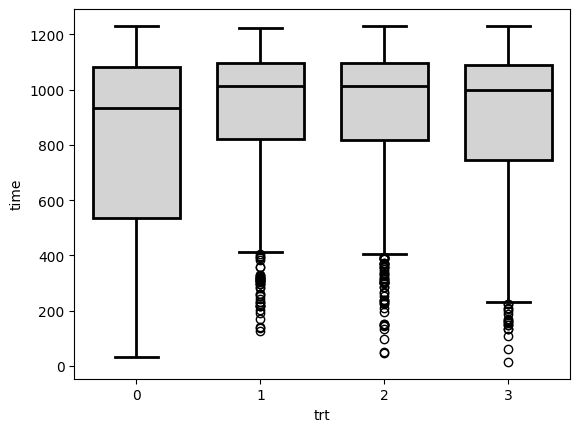

In [45]:
# fig, axes = plt.subplots(1, 2)
sns.boxplot(data=aids, x='trt', y='time', color='lightgrey', 
            linecolor='black', linewidth=2, width=0.7)#, ax=axes[0])
# sns.boxplot(data=aids, x='homo', y='time', color='lightgrey', 
#             linecolor='black', linewidth=2, width=0.7, ax=axes[1])
plt.show()